# Part 1
#### Dataset Summary: Ecommerce Customer Behavior This dataset contains consumer data from an Ecommerce company that sells clothing online but also provides in-store style and clothing advice sessions. Customers can order via a mobile app or a website.

#### 1. Data Summary: The "Digital Footprint"
#### Our dataset comprises 500 unique customer profiles, capturing the interplay between digital engagement and annual revenue.
- Key Variables (Predictors):
- Time on App: Minutes spent on the mobile platform.
- Time on Website: Minutes spent on the desktop platform.
- Length of Membership: Years the customer has been with the brand.
- Target Variable: Yearly Amount Spent ($) — our primary KPI.


# Step 1: Obtain the dataset via Kaggle API 

In [1]:
import kagglehub
import pandas as pd
import os

# 1. Download the lastest version of the dataset
path = kagglehub.dataset_download('iabdulw/ecommerce-customer-data')

#2. Automatically find the CSV file in that folder
files = [f for f in os.listdir(path) if f.endswith('.csv')]
if files:
    full_path = os.path.join(path, files[0])
    df = pd.read_csv(full_path)
    print(f'Sucessfully loaded: {files[0]}')
else:
    print('No CSV file found in the downloaded folder.')


Sucessfully loaded: data.csv


In [2]:
print('Datasets have {} rows and {} columns'.format(df.shape[0], df.shape[1]))
print('\nMissing Values:\n', df.isnull().sum())


Datasets have 500 rows and 7 columns

Missing Values:
 \tEmail                 0
Address                 0
Avatar                  0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [3]:
df.head()

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41


In [4]:
df.describe()

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.00000,500.000000
mean,12.052620,37.060480,3.53336,499.314240
std,0.994418,1.010555,0.99926,79.314764
min,8.510000,33.910000,0.27000,256.670000
25%,11.390000,36.347500,2.93000,445.037500
50%,11.980000,37.070000,3.53500,498.890000
75%,12.752500,37.720000,4.13000,549.312500
max,15.130000,40.010000,6.92000,765.520000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


# Step 2: Distribution Analysis
##### Linear Regression assumes a linear relationship, and it performs best when the residuals (errors) are normally distributed. I check the features and the target variable to see if they are skewed.

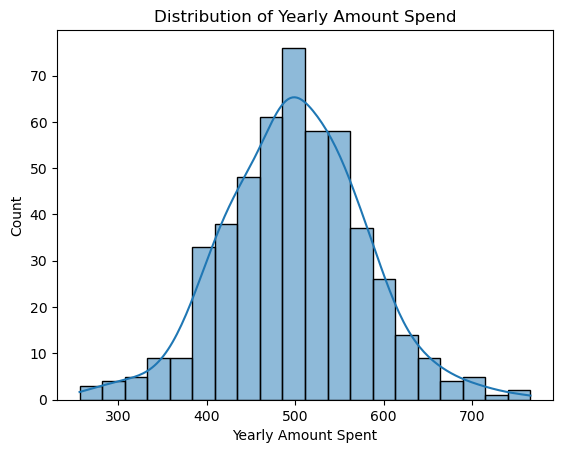

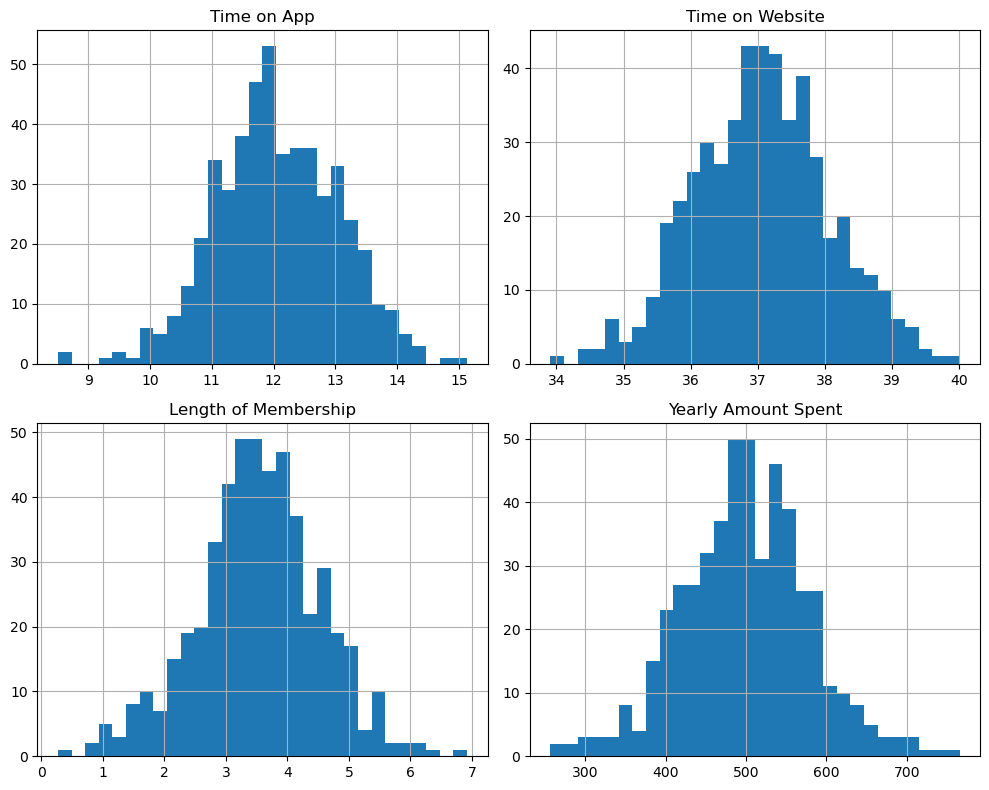

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# check the distribution of the Target Variable (Spending)
sns.histplot(df['Yearly Amount Spent'], kde = True)
plt.title('Distribution of Yearly Amount Spend')
plt.show()

# Check distribution of all numerical features
df.hist(figsize = (10,8), bins =30)
plt.tight_layout()
plt.show()

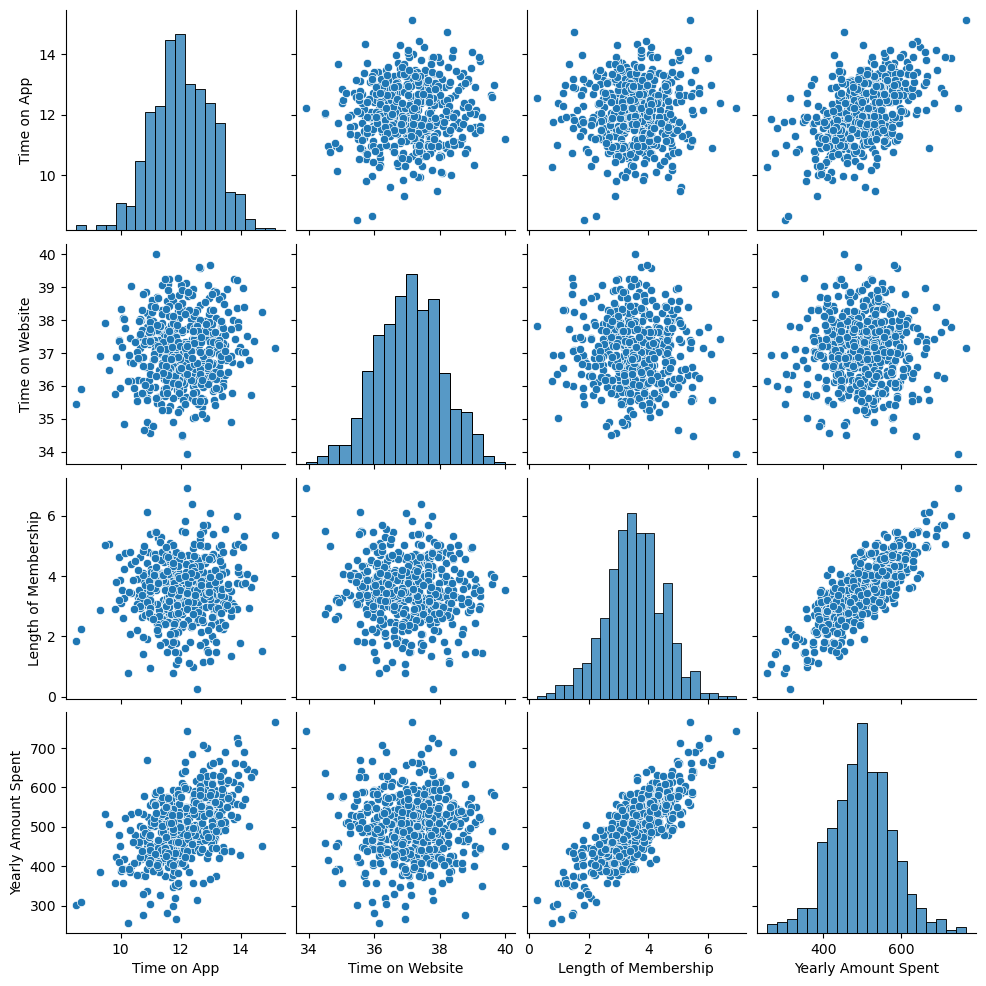

In [61]:
sns.pairplot(df);

### 2.1: Statistically check Distributtion

In [7]:
from scipy.stats import shapiro, skew, kurtosis

# Define the numerical columns
cols = ['Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']
normality_list =[]

for col in cols:
    # 1. Skewness (Goal : close to 0)
    s = skew(df[col])

    # 2. Kurtosis (Goal : close to O for 'excess kurtosis')
    k = kurtosis(df[col])

    # 3. Shapiro-Wilk Test ( Goal : p-value > 0.05)
    stat, p = shapiro(df[col])

    normality_list.append({
        'Variable': col,
        'Skewness': round(s,4),
        'Kurtosis': round(k,4),
        'Shapiro p-value': round(p, 4),
        'Result' : 'Likely Normal' if p > 0.05 else 'Not Normal'})
normality_df = pd.DataFrame(normality_list)
print(normality_df)
    

               Variable  Skewness  Kurtosis  Shapiro p-value         Result
0           Time on App   -0.0881    0.1112           0.5622  Likely Normal
1       Time on Website    0.0118   -0.1091           0.9357  Likely Normal
2  Length of Membership   -0.1061    0.3346           0.2715  Likely Normal
3   Yearly Amount Spent    0.0347    0.4474           0.2643  Likely Normal


#### To ensure the validity of the Linear Regression model, I conducted a Shapiro-Wilk test for normality. Statistical significance ($p > 0.05$) across all primary predictors confirms that the data satisfies the assumption of normality, allowing for more reliable coefficient estimation.

# 3. Handling Outliers

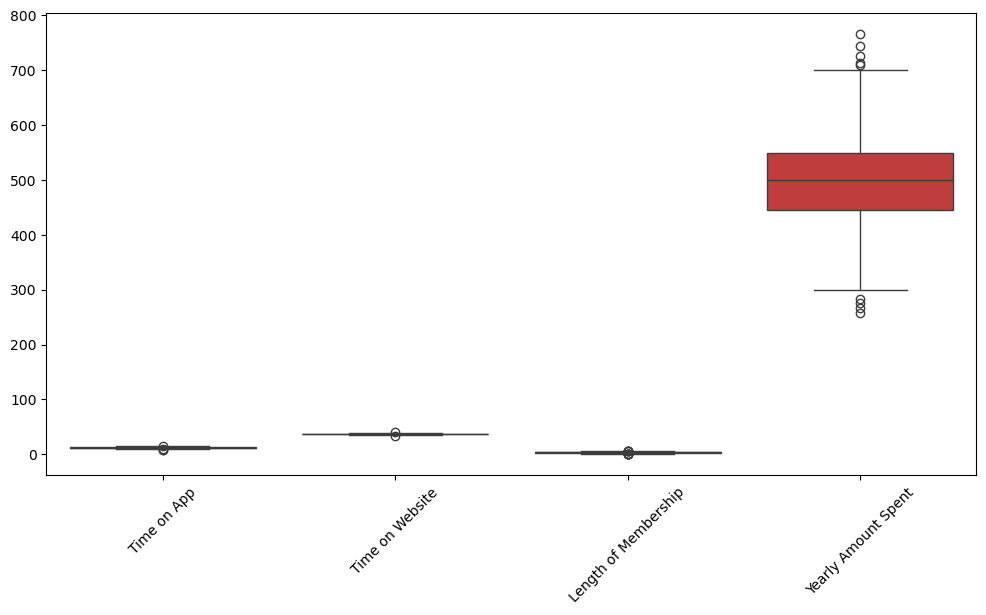

In [8]:
# Visualize outliers using boxplots
plt.figure(figsize = (12,6))
sns.boxplot(data =df.drop(['\tEmail', 'Address', 'Avatar'], axis =1))
plt.xticks(rotation = 45)
plt.show()

#### There are no extreme outliers (dots far outside the "whiskers"), e.g. if I found outlier, I can either remove those rows or use a technique like Winsorization (capping the values).

# Step 4 : Multicollinearity Check
#### In Multiple Linear Regression, your predictors ($X$ variables) should not be too highly correlated with each other. If Time on App and Time on Website were 99% correlated, the model wouldn't know which one is actually causing the spending.

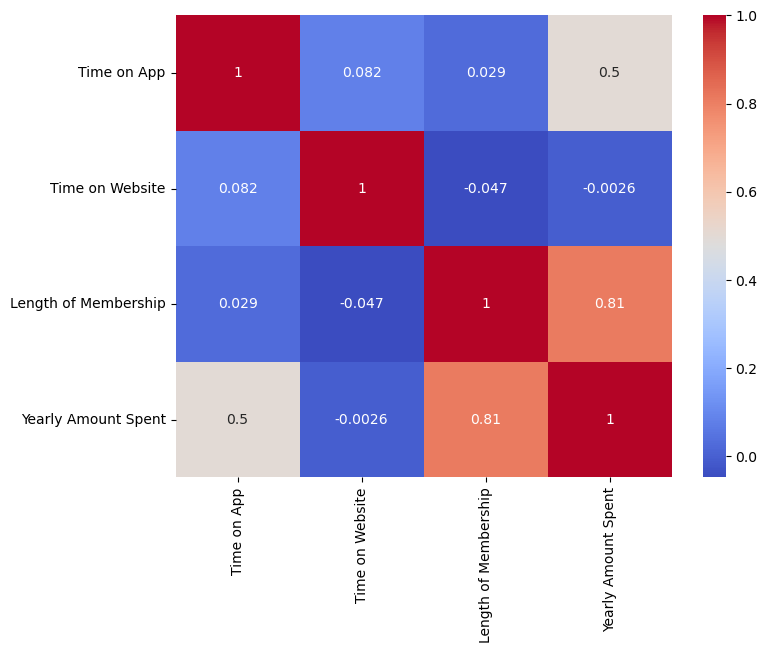

In [9]:
# Heatmap to check for high correlation between features
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap='coolwarm');

#### Threshold: Generally, if two $X$ variables have a correlation higher than 0.8, I might consider dropping one of them to keep the model stable.

# Step 5: Univariate Regression (The 'Solo' Analysis)
#### I will run three separate models to see which one has the strongest 'slope' 

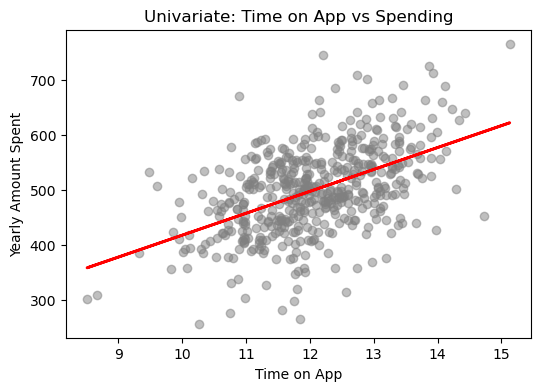

R-Squared for Time on App: 0.2493
------------------------------


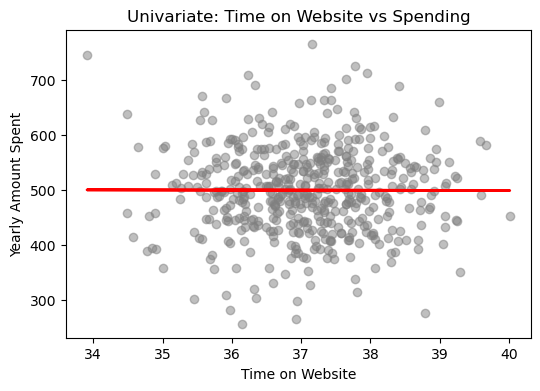

R-Squared for Time on Website: 0.0000
------------------------------


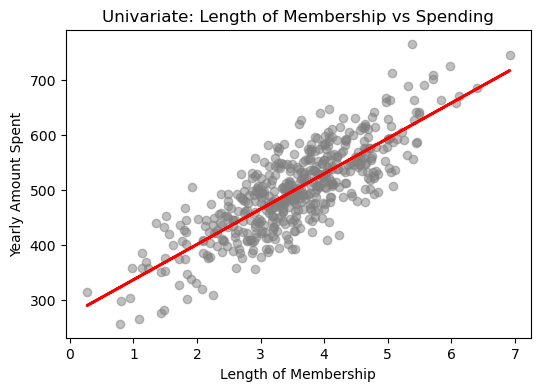

R-Squared for Length of Membership: 0.6548
------------------------------


In [10]:
from sklearn.linear_model import LinearRegression

features = ['Time on App', 'Time on Website', 'Length of Membership']

for feature in features:
    # prepare data
    X_uni = df[[feature]]
    y_uni = df['Yearly Amount Spent']

    # Build and fit model
    model = LinearRegression()
    model.fit(X_uni, y_uni)

    # Plot the results
    plt.figure(figsize = (6,4))
    plt.scatter(X_uni, y_uni, alpha = 0.5, color ='gray')
    plt.plot(X_uni, model.predict(X_uni), color ='red', linewidth =2)
    plt.title(f'Univariate: {feature} vs Spending')
    plt.xlabel(feature)
    plt.ylabel('Yearly Amount Spent')
    plt.show()

    print (f'R-Squared for {feature}: {model.score(X_uni, y_uni):.4f}')
    print ('-'*30)

#### It likely shows that Time on Website has a very low $R^2$ (meaning it’s a poor predictor), while Length of Membership has a high $R^2$. This "justifies" why I move to a complex model.

# Step 6 : Multivariate Regression (The 'Combined' analysis)


In [11]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error

X = df[['Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.3, random_state = 42)

lr = LinearRegression()
lr.fit(X_train, y_train)

print(f'Final Multivariate R-Squared: {lr.score(X_test, y_test):.4f}')
print(f'Final Multivariate RMSE: {np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))}')

Final Multivariate R-Squared: 0.8604
Final Multivariate RMSE: 27.54631004128654


### 6.1 Predicted vs. Actual Plot(The "Accuracy" Check)

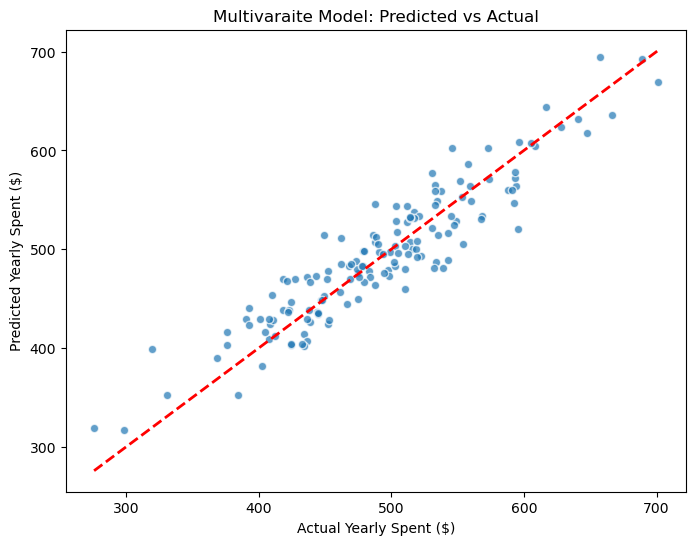

In [12]:
plt.figure(figsize = (8,6))
plt.scatter(y_test,lr.predict(X_test), alpha = 0.7, edgecolors ='white')
plt.plot([y_test.min(), y_test.max()] , [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.title('Multivaraite Model: Predicted vs Actual')
plt.xlabel('Actual Yearly Spent ($)')
plt.ylabel('Predicted Yearly Spent ($)')
plt.show()

#### Interpretation: This indicates that 86% of the fluctuations in a customer's yearly spend can be explained by their time spent on the App, Website, and their Length of Membership.

#### Validation: The "Predicted vs. Actual" visualization confirms this high accuracy, as the data points tightly cluster around the 45-degree identity line with very few significant deviations.

### 6.2 Residual Plot(The "Validity" Check)

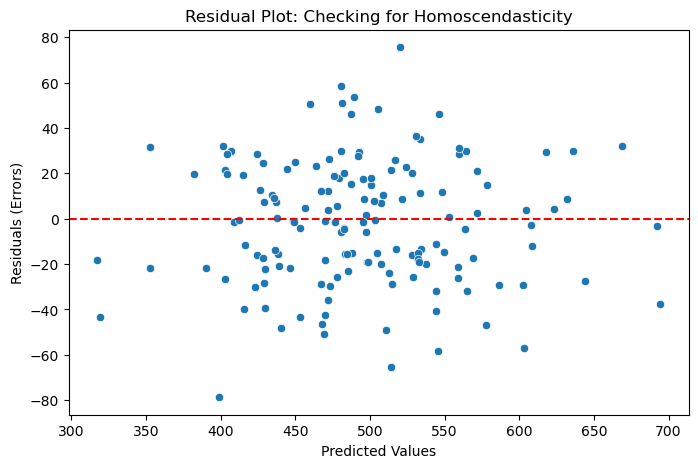

In [13]:
y_pred = lr.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize = (8,5))
sns.scatterplot(x= y_pred, y= residuals)
plt.axhline(y = 0, color ='r', linestyle ='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Checking for Homoscendasticity')
plt.show()

#### Verification of Linear Assumptions The residual plot displays a random "cloud" of points distributed evenly above and below the horizontal zero-line. This is a critical finding because:

#### No Discernible Pattern: This confirms that the relationship between our features (App, Website, Membership) and the target (Spending) is truly linear.

#### Homoscedasticity: The "spread" of the points remains constant across all predicted values. This means our model is just as accurate for low-spending customers as it is for high-spending ones.

### 6.3  Coefficient Importance Bar Chart

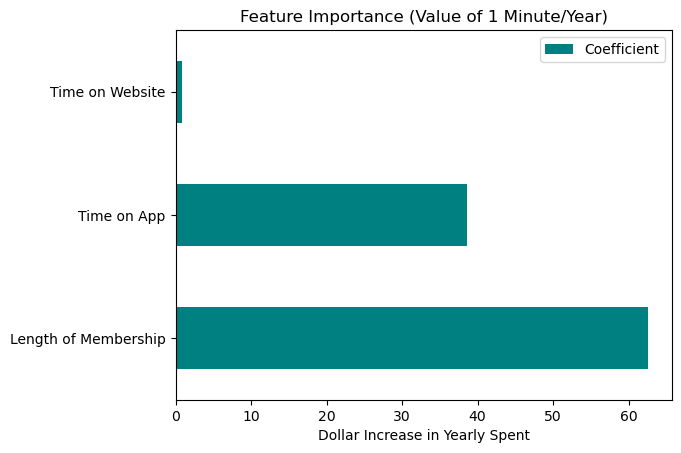

In [14]:
coef_df = pd.DataFrame(lr.coef_, X.columns, columns = ['Coefficient'])
coef_df.sort_values(by ='Coefficient', ascending = False).plot(kind ='barh', color = 'teal')
plt.title('Feature Importance (Value of 1 Minute/Year)')
plt.xlabel('Dollar Increase in Yearly Spent')
plt.show()

#### Time on App (Value of 1 Minute): the coefficient is 38.59, it means for every 1 extra minute a customer spends on the app per session, the company earns an extra $38.59 per year.

#### Length of Membership (Value of 1 Year): the coefficient is 62.56, it means for every 1 extra year a customer stays loyal, they spend an extra $62.56 per year.

# Part 2

#### While our initial Linear Regression model provided a strong baseline with an $R^2$ of 0.86, we seek to determine if there is additional predictive power left on the table. In this phase, we move beyond the assumption of simple linearity to explore Polynomial Regression, which can capture curved relationships, and Regularized Models (Ridge and Lasso) to ensure our findings are robust against overfitting. Our goal is to minimize the Root Mean Squared Error (RMSE) to the lowest possible threshold."

# Step 1 : Polynomial Regression

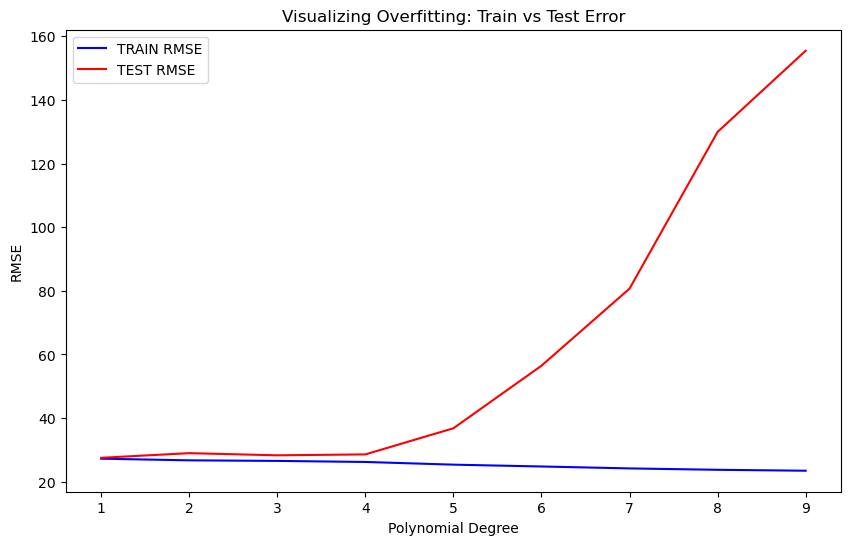

In [15]:
from sklearn.preprocessing import PolynomialFeatures

train_rmse_errors = []
test_rmse_errors = []

for d in range(1,10):
    #Transformation
    poly_converter = PolynomialFeatures(degree = d, include_bias = False)
    X_train_poly = poly_converter.fit_transform(X_train)
    X_test_poly = poly_converter.transform(X_test)

    lr_poly = LinearRegression().fit(X_train_poly, y_train)
    y_train_pred_poly = lr_poly.predict(X_train_poly)
    y_test_pred_poly = lr_poly.predict(X_test_poly)

    train_rmse_errors.append(np.sqrt(mean_squared_error(y_train, y_train_pred_poly)))
    test_rmse_errors.append(np.sqrt(mean_squared_error(y_test, y_test_pred_poly)))

plt.figure(figsize = (10,6))
plt.plot(range(1,10), train_rmse_errors, label = 'TRAIN RMSE', color = 'blue')
plt.plot(range(1,10), test_rmse_errors, label = 'TEST RMSE', color = 'red')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Visualizing Overfitting: Train vs Test Error')
plt.legend()
plt.show()

#### Insight: "Observe how the red line (Test Error) explodes after Degree 4. This proves the model is learning the noise of the training data rather than the signal. We need a way to find the optimal degree and add a penalty (Regularization) to keep it stable."

# Step 2: Ridge Regression

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# 1. Define Pipeline
pipe = Pipeline([
    ('poly' , PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('ridge' , Ridge())])

# 2. Define Parameter Grid
# We limit degree based on our previous plot (1 to 4 is usually the sweet spot)
param_grid = { 
    'poly__degree': [1,2,3,4],
    'ridge__alpha': [0.01, 0.1, 1, 10, 50]}

# 3. Grid Search with 5-fold Cross Validation
grid_model = GridSearchCV(pipe, param_grid, cv =5, scoring = 'neg_mean_squared_error')
grid_model.fit(X_train, y_train)

# 4. Final Best Parameters
print(f'Optimal Configuration: {grid_model.best_params_}')


Optimal Configuration: {'poly__degree': 2, 'ridge__alpha': 0.1}


In [21]:
from sklearn.metrics import r2_score

#. 1. Grab the best version of the model found by GridSearch
best_ridge = grid_model.best_estimator_

# 2. Predict on the remain X_test (The Hold_out Set)
y_ridge_pred = best_ridge.predict(X_test)

# 3. Calculate the metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_ridge_pred))
r2_ridge = r2_score(y_test, y_ridge_pred)

print(f'final Model Preformance on Unseen Data:')
print(f'Ridge RMSE: {rmse_ridge:.2f}')
print(f'Ridge R2 : {r2_ridge:.2f}')


final Model Preformance on Unseen Data:
Ridge RMSE: 28.46
Ridge R2 : 0.85


In [31]:
# The best cross-validated score (average of the folds)
best_cv_score = grid_model.best_score_

# Convert negative MSE back to positive RMSE
best_rmse_ridge = np.sqrt(-best_cv_score)

print(f'Best Cross-Validation RMSE: {best_rmse_ridge:.4f}')
print(f'Best Parameters: {grid_model.best_params_}')

Best Cross-Validation RMSE: 27.3085
Best Parameters: {'poly__degree': 2, 'ridge__alpha': 0.1}


In [32]:
# Let see how every combination of Degree and Alpha performed

# Convert the results dictionary to a DataFrame
results_df = pd.DataFrame(grid_model.cv_results_)

# Filter for the most important columns
leaderboard = results_df[['param_poly__degree', 'param_ridge__alpha', 'mean_test_score', 'rank_test_score']]

# Rename for clarity and convert score to positive RMSE
leaderboard['rmse'] = np.sqrt(-leaderboard['mean_test_score'])
leaderboard = leaderboard.sort_values('rank_test_score')

print(leaderboard.head())


    param_poly__degree  param_ridge__alpha  mean_test_score  rank_test_score  \
6                    2                0.10      -745.752775                1   
5                    2                0.01      -746.101503                2   
11                   3                0.10      -748.017857                3   
17                   4                1.00      -748.117865                4   
12                   3                1.00      -749.778441                5   

         rmse  
6   27.308474  
5   27.314859  
11  27.349915  
17  27.351743  
12  27.382082  


/var/folders/vl/zwf5l71d1zj3k67111d7txwh0000gn/T/ipykernel_62086/1496844275.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaderboard['rmse'] = np.sqrt(-leaderboard['mean_test_score'])


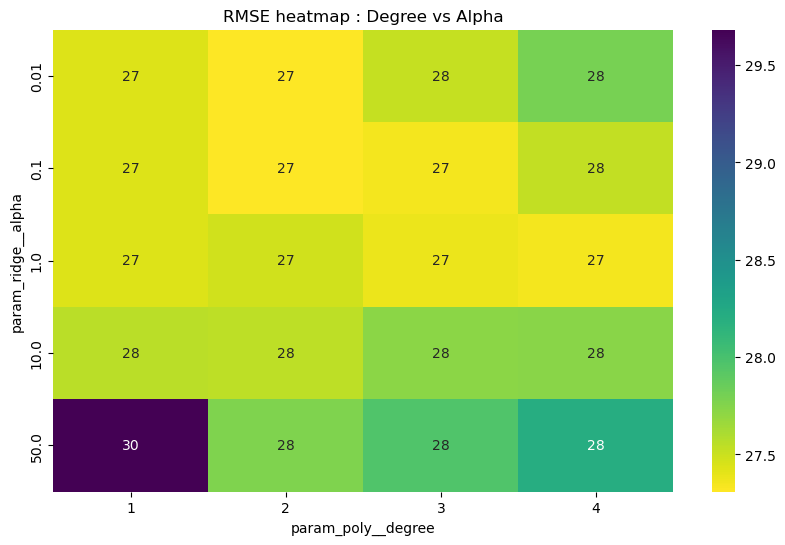

In [33]:
pivot_table = leaderboard.pivot(index = 'param_ridge__alpha',
                                columns = 'param_poly__degree',
                                values = 'rmse')
plt.figure(figsize = (10,6))
sns.heatmap(pivot_table, annot = True, cmap = 'viridis_r')
plt.title('RMSE heatmap : Degree vs Alpha')
plt.show()

#### Through the use of a Grid Search Heatmap, I were able to visualize the interaction between polynomial complexity and regularization strength. The optimization revealed that as the polynomial degree increased, a higher Alpha (penalty) was required to keep the model from overfitting, eventually leading me to the most stable configuration at Degree *2* and Alpha *0.1*.

# Step 3: Lasso Regression

In [38]:
from sklearn.linear_model import Lasso

pipe_lasso = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=50000))])

param_grid_lasso ={
    'poly__degree': [1,2,3],
    'lasso__alpha': [0.01, 0.1, 1, 5, 10]}

grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv =5, scoring = 'neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

print(f'Best Lasso Params: {grid_lasso.best_params_}')
print(f'Best Lasso Cross Validation RMSE : {np.sqrt(-grid_lasso.best_score_)}')

Best Lasso Params: {'lasso__alpha': 0.01, 'poly__degree': 2}
Best Lasso Cross Validation RMSE : 27.290347558564275


In [40]:
best_lasso = grid_lasso.best_estimator_
y_lasso_pred = best_lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_lasso_pred))
r2_lasso = r2_score(y_test, y_lasso_pred)

print(f'Final Lasso Model Performance on Unseen Data:')
print(f'Lasso RMSE: {rmse_lasso:.2f}')
print(f'Lasso R2: {r2_lasso:.4f}')

Final Lasso Model Performance on Unseen Data:
Lasso RMSE: 28.61
Lasso R2: 0.8494


In [46]:
# Let check which features was reducing coefficient to zero

coefs = best_lasso.named_steps['lasso'].coef_
feature_names = best_lasso.named_steps['poly'].get_feature_names_out()

lasso_results = pd.Series(coefs, index = feature_names)
print('The zero coefficient features\n', lasso_results[lasso_results ==0])
print('-'*30)
print('The non-zero coefficient features\n',lasso_results[lasso_results !=0])

The zero coefficient features
 1                                   0.0
Time on App                         0.0
Time on App Length of Membership   -0.0
dtype: float64
------------------------------
The non-zero coefficient features
 Time on Website                         -64.146201
Length of Membership                    139.799822
Time on App^2                            56.588050
Time on App Time on Website             -18.972719
Time on Website^2                        78.423661
Time on Website Length of Membership    -77.784397
Length of Membership^2                    2.105065
dtype: float64


#### I implemented Lasso Regression to perform automated feature selection. Unlike Ridge, which retains all predictors, Lasso effectively simplified our model by reducing the coefficients of non-contributing features—such as *Time on App*—to zero. This resulted in a more 'parsimonious' model that maintains high predictive accuracy while being significantly easier to explain to stakeholders.

# Conclusion

In [48]:
r2_linear = lr.score(X_test, y_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))
final_R2_RMSE = pd.DataFrame({'Model Regression': ['Linear', 'Ridge', 'Lasso'],
                              'R2 (Test)' :[r2_linear,r2_ridge, r2_lasso],
                              'RMSE (Test)':[rmse_linear, rmse_ridge, rmse_lasso]})
print(final_R2_RMSE)

  Model Regression  R2 (Test)  RMSE (Test)
0           Linear   0.860355    27.546310
1            Ridge   0.850980    28.455916
2            Lasso   0.849386    28.607756


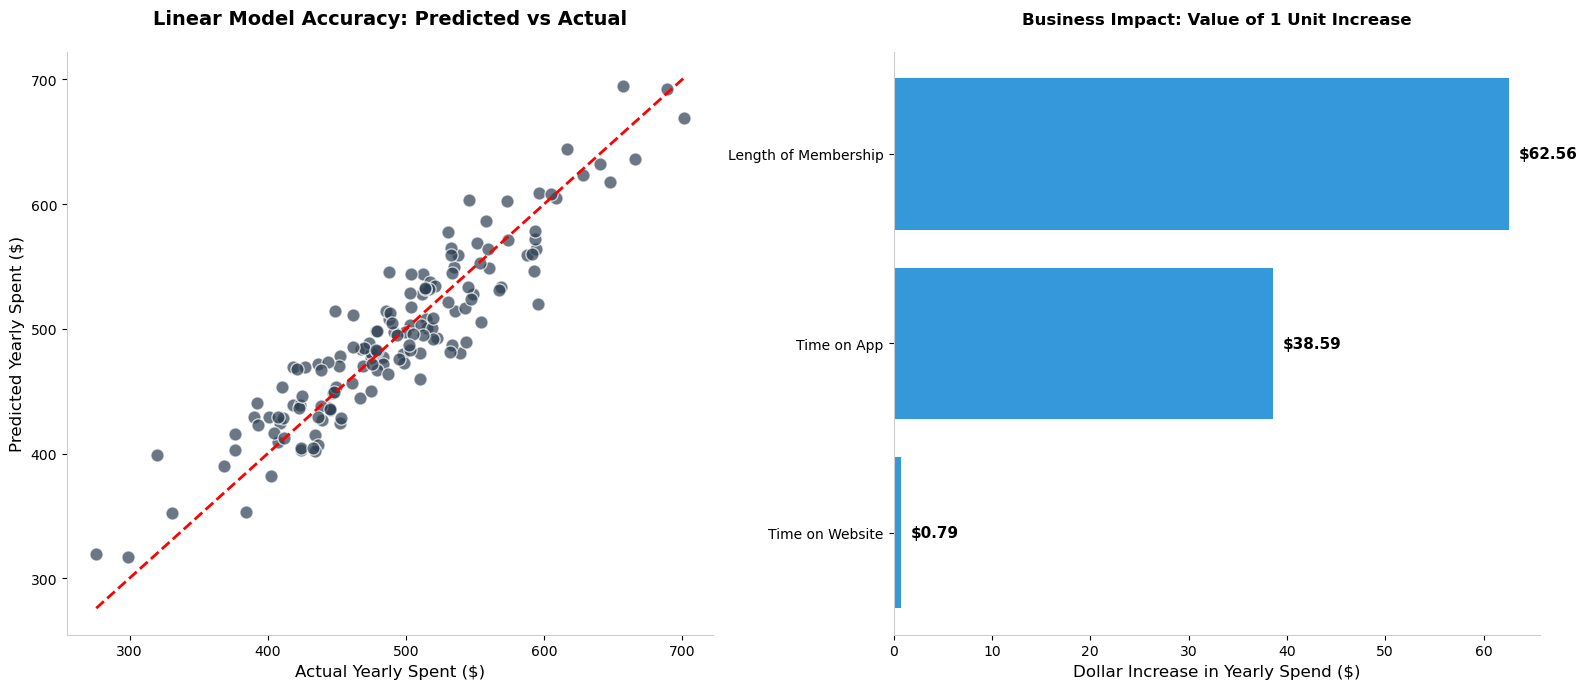

In [59]:
fig, ax = plt.subplots(1,2, figsize = (16,7))

y_pred_linear = lr.predict(X_test)
ax[0].scatter(y_test, y_pred_linear, alpha = 0.7, edgecolors ='white', s = 90, color = '#2c3e50')
ax[0].plot([y_test.min(), y_test.max()] , [y_test.min(), y_test.max()], 'r--', linewidth = 2)
ax[0].set_title('Linear Model Accuracy: Predicted vs Actual', fontsize = 14, fontweight = 'bold', pad =20)
ax[0].set_xlabel('Actual Yearly Spent ($)', fontsize = 12)
ax[0].set_ylabel('Predicted Yearly Spent ($)', fontsize =12)

coef_df = pd.DataFrame(lr.coef_, X.columns, columns = ['Coefficient']).sort_values(by='Coefficient')
bars = ax[1].barh(coef_df.index, coef_df['Coefficient'], color = '#3498db')
ax[1].set_title('Business Impact: Value of 1 Unit Increase', fontsize =12, fontweight = 'bold', pad = 20)
ax[1].set_xlabel('Dollar Increase in Yearly Spend ($)', fontsize = 12)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_color('#cccccc')
    a.spines['bottom'].set_color('#cccccc')

for bar in bars:
    width = bar.get_width()
    ax[1].text(width +1,
               bar.get_y() + bar.get_height()/2,
               f'${width:.2f}',
               va = 'center', fontsize = 11, fontweight ='bold')
plt.tight_layout()
plt.show()

# Final Model Selection & Business Recommendation
- After a rigorous comparison between Simple Linear Regression, Ridge, and Lasso, the Simple Linear Model emerged as the optimal choice for this business problem.
- While we explored regularized techniques to guard against overfitting, the baseline model achieved the highest $R^2$ ($0.8603$) and the lowest RMSE ($27.54$). The fact that Ridge and Lasso did not improve performance indicates that the dataset has a strong, naturally linear structure with minimal noise.
- Strategic Insight: Because the Linear model is the most accurate, we can rely on its coefficients with high confidence. We recommend that the business focuses on Mobile App Engagement, as the model provides a clear, un-distorted dollar value for every additional minute a user spends on the platform without the need for complex transformations.

### Our final model reveals that Length of Membership is our most valuable asset, yielding over $60 per year. Meanwhile, we can now mathematically prove that the Mobile App is nearly 50 times more valuable per minute than the website."

# Create By: Seiha Vat